In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from scipy import stats
import warnings 
warnings.filterwarnings('ignore')

train = pd.read_csv("./input/train.csv")
test = pd.read_csv("./input/test.csv")

display(train.head(n=1))

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500


In [3]:
train.shape

(1460, 81)

In [4]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


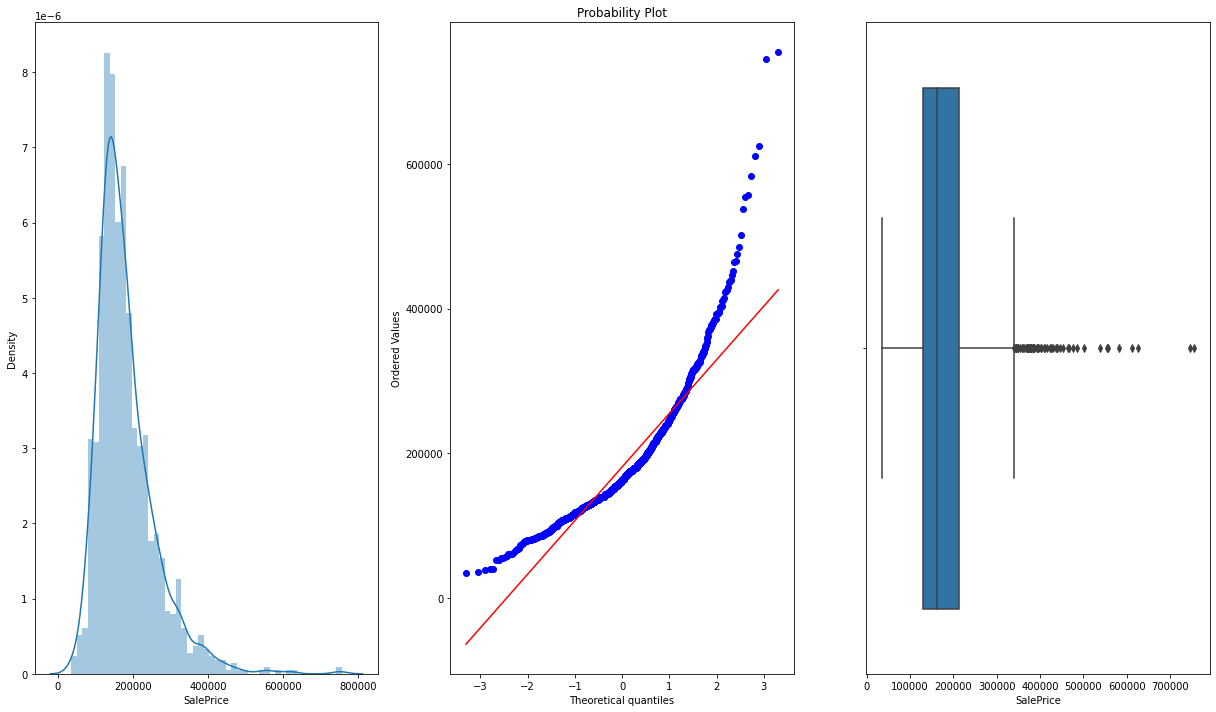

In [7]:
plt.figure(figsize=(17,10))
plt.subplot(131)
sns.distplot(train["SalePrice"])

plt.subplot(132)
stats.probplot(train["SalePrice"], plot=plt)

plt.subplot(133)
sns.boxplot(train["SalePrice"])
plt.tight_layout()

plt.show()

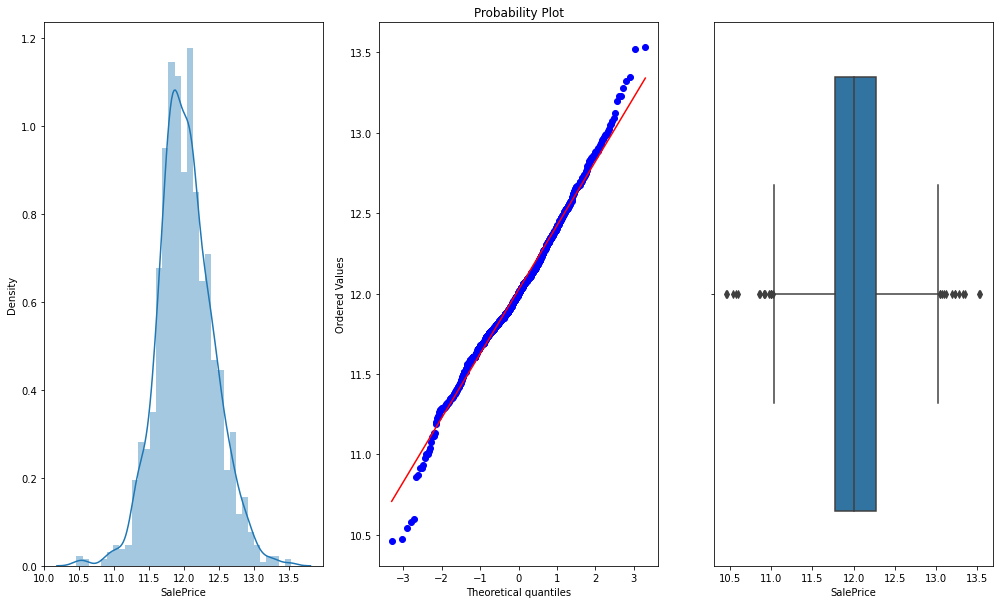

In [8]:
normalized_price = np.log1p(train["SalePrice"])
plt.figure(figsize=(17,10))

plt.subplot(131)
sns.distplot(normalized_price)

plt.subplot(132)
stats.probplot(normalized_price, plot=plt)

plt.subplot(133)
sns.boxplot(normalized_price)

plt.show()


In [18]:
train["MSSubClass"] = train["MSSubClass"].astype("str")

In [24]:
numerical_features =[]
categorical_features=[]
for f in train.columns:
    if train[f].dtypes != 'object':
        numerical_features.append(f)
    else:
        categorical_features.append(f)

In [34]:
numerical_features

['Id',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice']

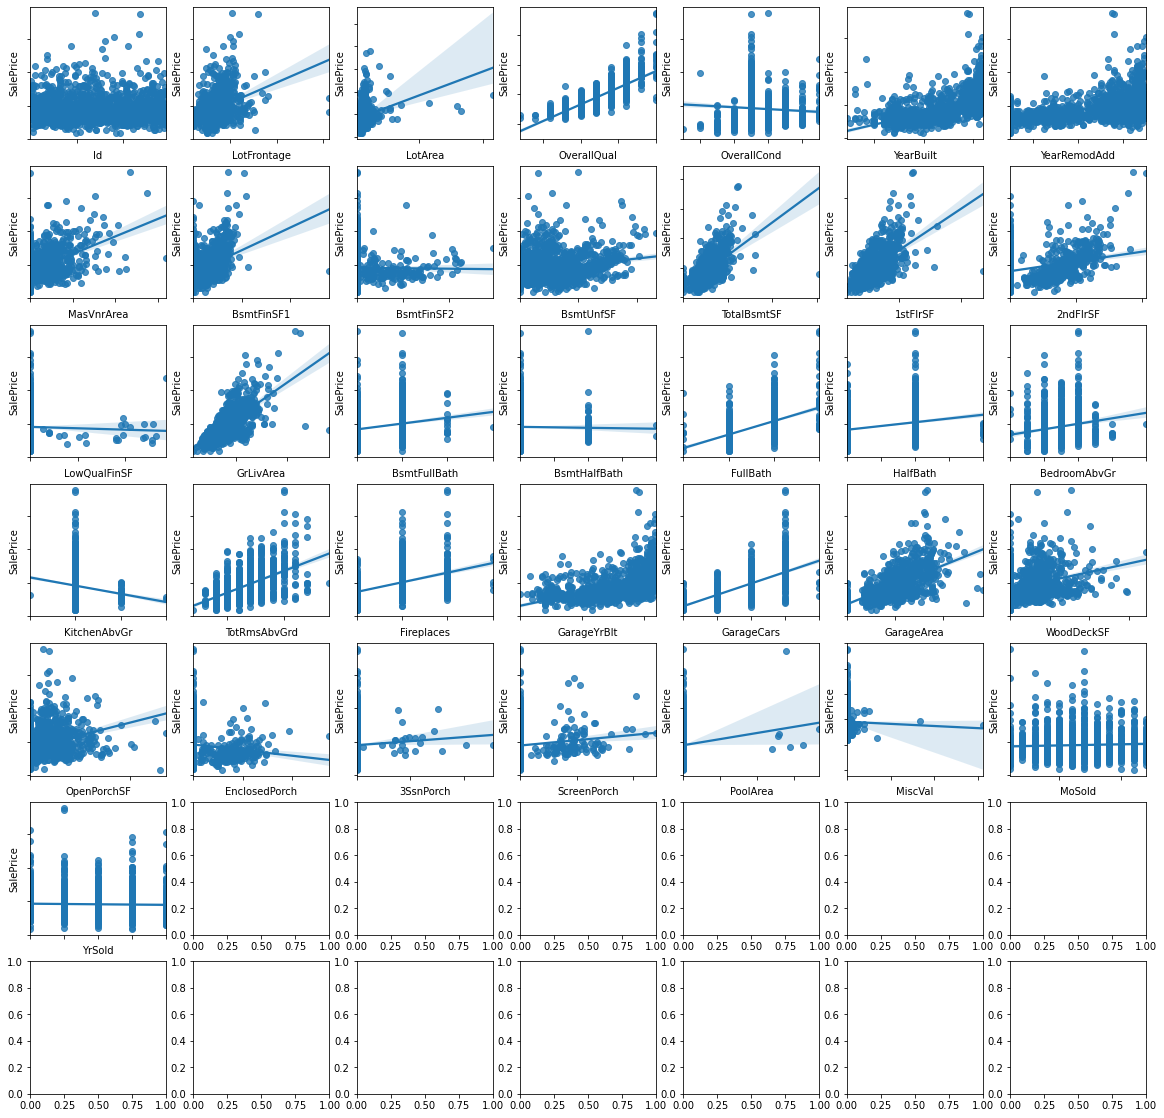

In [37]:
fig, ax = plt.subplots(7,7,figsize=(20,20))

for idx, n in enumerate(numerical_features):
    if n == "SalePrice":
        continue
    sns.regplot(x=n, y="SalePrice", data=train, ax = ax[idx//7, idx%7])
    ax[idx//7,idx%7].set(xticklabels=[])
    ax[idx//7, idx%7].set(yticklabels=[])

In [39]:
len(categorical_features)

44

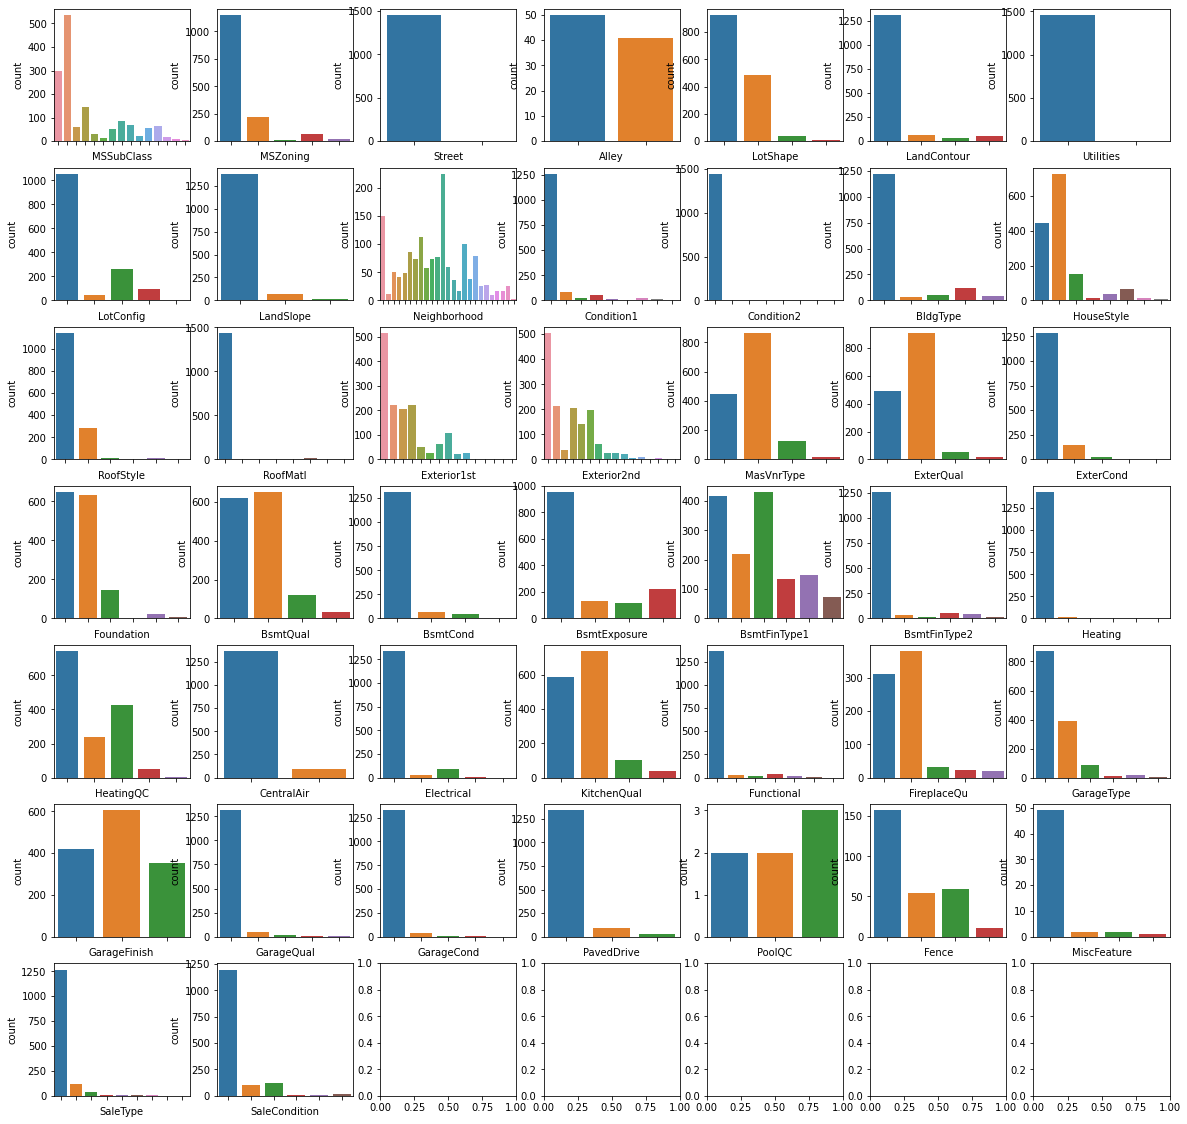

In [42]:
fig, ax = plt.subplots(7,7,figsize=(20,20))

for idx, c in enumerate(categorical_features):
    sns.countplot(x=c, data=train, ax=ax[idx//7, idx%7])
    ax[idx//7,idx%7].set(xticklabels=[])


In [51]:
df_train = train.copy()

In [52]:
df_train["2ndFloor"] = "2ndFloor"

In [57]:
df_train["2ndFloor"].loc[df_train["2ndFlrSF"]==0]="No 2ndfloor"

AttributeError: 'AxesSubplot' object has no attribute 'fig'

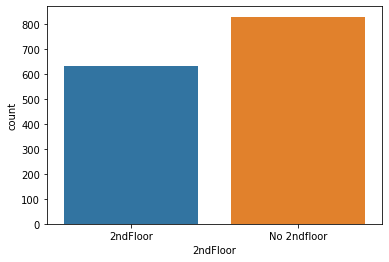

In [73]:
floor = sns.countplot(x="2ndFloor", data=df_train)
floor.fig.set_size_inches(15,5)

In [58]:
df_train["basement"]= "basement"

In [60]:
df_train["basement"].loc[df_train["TotalBsmtSF"]==0]="No basement"

In [ ]:
df_train["GrLivArea"]

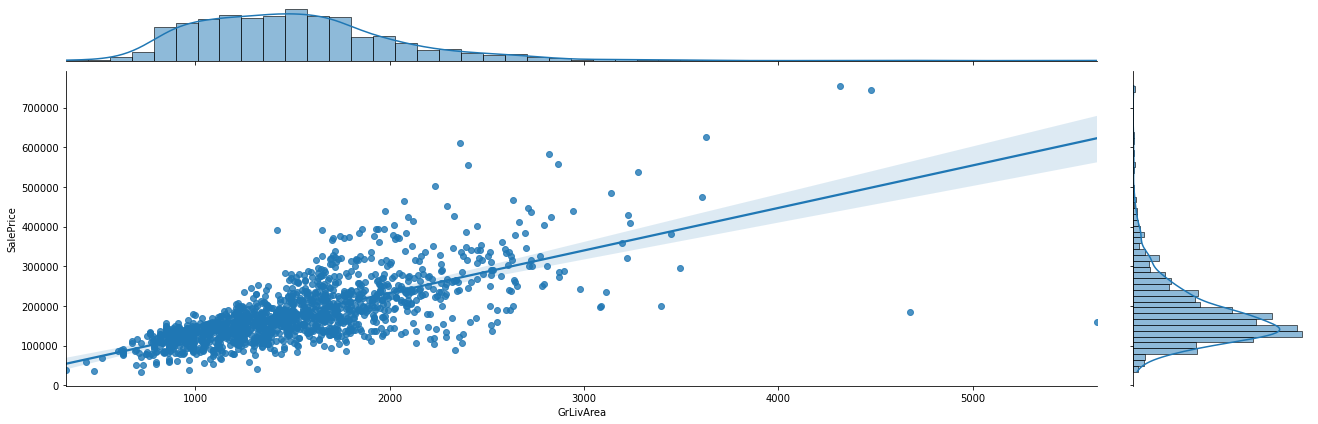

In [78]:
grid = sns.jointplot(x = "GrLivArea", y="SalePrice", data = df_train, kind="reg")
grid.fig.set_size_inches(20,6)